In [1]:
# ── CELL 0-1: Imports ────────────────────────────────────────────────────────
import json, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# ── CELL 0-2: Paths ──────────────────────────────────────────────────────────
# BUG 8 FIX: GAMMAS is the single source of truth. MCBM_FEATS is built from it.
# Never redefine GAMMAS anywhere below.

ROOT     = Path("/scratch/network/cr7998/cv_emergence_project")
CUB      = ROOT / "data" / "CUB_200_2011"
ATTR_TXT = ROOT / "data" / "attributes.txt"

GAMMAS     = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
MCBM_FEATS = {g: ROOT / "features" / f"resnet50_mcbm_gamma{g}" for g in GAMMAS}

assert CUB.exists(),      f"Missing: {CUB}"
assert ATTR_TXT.exists(), f"Missing: {ATTR_TXT}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
for g, p in MCBM_FEATS.items():
    print(f"  gamma={g}: exists={p.exists()}  ({p.name})")

device: cpu
  gamma=0.0: exists=True  (resnet50_mcbm_gamma0.0)
  gamma=0.05: exists=False  (resnet50_mcbm_gamma0.05)
  gamma=0.1: exists=True  (resnet50_mcbm_gamma0.1)
  gamma=0.2: exists=False  (resnet50_mcbm_gamma0.2)
  gamma=0.3: exists=False  (resnet50_mcbm_gamma0.3)
  gamma=0.5: exists=True  (resnet50_mcbm_gamma0.5)
  gamma=1.0: exists=True  (resnet50_mcbm_gamma1.0)


In [3]:
# ── CELL 0-3: Layer + emergence settings — defined once, never hardcoded ──────
LAYERS = [
    "conv1",
    "layer1.0", "layer1.1", "layer1.2",
    "layer2.0", "layer2.1", "layer2.2", "layer2.3",
    "layer3.0", "layer3.1", "layer3.2", "layer3.3", "layer3.4", "layer3.5",
    "layer4.0", "layer4.1", "layer4.2",
    "avgpool",
]
EMERGE_METRIC = "balanced"   # "balanced" | "plain"
EMERGE_FRAC   = 0.90

print(f"EMERGE_METRIC : {EMERGE_METRIC}")
print(f"EMERGE_FRAC   : {EMERGE_FRAC}")
print(f"Layers        : {len(LAYERS)}  ({LAYERS[0]} → {LAYERS[-1]})")

EMERGE_METRIC : balanced
EMERGE_FRAC   : 0.9
Layers        : 18  (conv1 → avgpool)


In [4]:
# ── CELL 1-1: Species name maps ───────────────────────────────────────────────
def load_species_maps(cub_root: Path):
    classes = pd.read_csv(
        cub_root / "classes.txt",
        sep=r"\s+", header=None,
        names=["species_id", "class_name"], engine="python",
    )
    def pretty(name: str) -> str:
        return name.split(".", 1)[-1].replace("_", " ")
    return dict(zip(classes["species_id"].astype(int),
                    classes["class_name"].map(pretty)))

species_id_to_name = load_species_maps(CUB)

def spname(sid: int) -> str:
    return species_id_to_name.get(int(sid), f"species_{sid}")

In [5]:
# ── CELL 1-2: Image metadata ──────────────────────────────────────────────────
def load_meta(cub_root: Path) -> pd.DataFrame:
    img_species = pd.read_csv(
        cub_root / "image_class_labels.txt",
        sep=r"\s+", header=None,
        names=["image_id", "species_id"], engine="python",
    )
    split_df = pd.read_csv(
        cub_root / "train_test_split.txt",
        sep=r"\s+", header=None,
        names=["image_id", "is_train"], engine="python",
    )
    meta = img_species.merge(split_df, on="image_id")
    meta["species_name"] = meta["species_id"].map(spname)
    return meta

meta = load_meta(CUB)
print(f"meta: {len(meta)} images, {meta['species_id'].nunique()} species")

meta: 11788 images, 200 species


In [6]:
# ── CELL 1-3: Attribute labels ────────────────────────────────────────────────
def load_image_attr_labels_robust(cub_root: Path) -> pd.DataFrame:
    path = cub_root / "attributes" / "image_attribute_labels.txt"
    rows, bad = [], 0
    with open(path) as f:
        for line in f:
            toks = line.strip().split()
            if len(toks) < 4:
                bad += 1; continue
            try:
                rows.append((int(toks[0]), int(toks[1]), int(toks[2]), int(toks[3])))
            except Exception:
                bad += 1
    df = pd.DataFrame(rows, columns=["image_id", "attr_id", "is_present", "certainty"])
    print(f"Parsed rows: {len(df)}  bad lines skipped: {bad}")
    return df

img_attr_long = load_image_attr_labels_robust(CUB)
img_attr_long.head()

Parsed rows: 3677856  bad lines skipped: 0


,image_id,attr_id,is_present,certainty
0,1,1,0,3
1,1,2,0,3
2,1,3,0,3
3,1,4,0,3
4,1,5,1,3


In [7]:
# ── CELL 1-4: Attribute name maps ─────────────────────────────────────────────
def load_attr_maps(attr_txt: Path):
    rows = []
    with open(attr_txt) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            aid_str, name = line.split(" ", 1)
            rows.append((int(aid_str), name))
    df = pd.DataFrame(rows, columns=["attr_id", "attr_name"])
    return df, dict(zip(df["attr_name"], df["attr_id"])), dict(zip(df["attr_id"], df["attr_name"]))

attr_df, attr_name_to_id, attr_id_to_name = load_attr_maps(ATTR_TXT)
print(f"attr_df: {len(attr_df)} attributes")
attr_df.head()

attr_df: 312 attributes


,attr_id,attr_name
0,1,has_bill_shape::curved_(up_or_down)
1,2,has_bill_shape::dagger
2,3,has_bill_shape::hooked
3,4,has_bill_shape::needle
4,5,has_bill_shape::hooked_seabird


In [8]:
# ── CELL 2-1: Safe tensor load + load_features ────────────────────────────────
def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")

def load_features(feat_dir: Path, layer: str, split: str) -> torch.Tensor:
    p = feat_dir / f"{layer}_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    X = safe_torch_load(p)
    return (X if isinstance(X, torch.Tensor) else torch.tensor(X)).float()

In [9]:
# ── CELL 2-2: Split order loading ─────────────────────────────────────────────
def to_1d_int_array(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.array(x).reshape(-1).astype(int)

def load_split_image_ids(feat_dir: Path, split: str) -> np.ndarray:
    p = feat_dir / f"labels_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    t = torch.load(p, map_location="cpu", weights_only=True)
    assert isinstance(t, dict) and "image_ids" in t, \
        f"{p} must be a dict with 'image_ids'; got {type(t)}, keys={list(t.keys()) if isinstance(t,dict) else 'N/A'}"
    return to_1d_int_array(t["image_ids"])

In [10]:
# ── CELL 2-3: Load split orders (once; shared across all gammas) ──────────────
_ref = MCBM_FEATS[0.0]
assert _ref.exists(), f"Reference feature dir missing: {_ref}"

mcbm_ids_tr = load_split_image_ids(_ref, "train")
mcbm_ids_te = load_split_image_ids(_ref, "test")

print(f"train ids: {len(mcbm_ids_tr)}  range [{mcbm_ids_tr.min()}, {mcbm_ids_tr.max()}]")
print(f"test  ids: {len(mcbm_ids_te)}  range [{mcbm_ids_te.min()}, {mcbm_ids_te.max()}]")

assert mcbm_ids_tr.max() > 200, "Expected image_ids (>200), not species_ids — check labels_train.pt"
assert mcbm_ids_te.max() > 200, "Expected image_ids (>200), not species_ids — check labels_test.pt"

train ids: 5994  range [2, 11787]
test  ids: 5794  range [1, 11788]


In [11]:
# ── CELL 2-4: Feature-to-label alignment ─────────────────────────────────────
def align_features_and_labels(
    X_split: torch.Tensor,
    image_ids_in_feature_order: np.ndarray,
    labeled_df_split: pd.DataFrame,
) -> tuple[torch.Tensor, pd.DataFrame]:
    labeled = labeled_df_split.set_index("image_id")[["y", "species_id", "species_name"]]
    keep_idx, rows = [], []
    for i, img_id in enumerate(image_ids_in_feature_order):
        img_id = int(img_id)
        if img_id in labeled.index:
            keep_idx.append(i)
            y, sid, sname = labeled.loc[img_id, ["y", "species_id", "species_name"]]
            rows.append((img_id, int(sid), str(sname), int(y)))
    X_aligned  = X_split[keep_idx]
    df_aligned = pd.DataFrame(rows,
                               columns=["image_id","species_id","species_name","y"])
    return X_aligned, df_aligned   # df_aligned always has fresh 0-based index

In [12]:
# ── CELL 2-5: Attribute label builder ────────────────────────────────────────
# BUG 1 FIX: CUB has multiple annotator rows per (image, attribute).
# After filtering, deduplicate by taking max is_present per image_id so that
# align_features_and_labels never sees duplicate image_ids.

def build_attr_labeled_df(
    meta: pd.DataFrame,
    img_attr_long: pd.DataFrame,
    attr_id: int,
    min_certainty: int = 1,
) -> pd.DataFrame:
    sub = img_attr_long[
        (img_attr_long["attr_id"] == int(attr_id)) &
        (img_attr_long["certainty"] >= int(min_certainty))
    ].copy()

    # Deduplicate: multiple annotators → keep max is_present per image
    sub = sub.groupby("image_id", as_index=False)["is_present"].max()

    out = meta.merge(sub[["image_id", "is_present"]], on="image_id", how="inner")
    out = out.rename(columns={"is_present": "y"})
    out["y"] = out["y"].astype(int)
    return out[["image_id", "species_id", "species_name", "is_train", "y"]]

# sanity check
_aid = attr_name_to_id["has_primary_color::yellow"]
_lab = build_attr_labeled_df(meta, img_attr_long, _aid, min_certainty=1)
print(f"Sanity: has_primary_color::yellow  rows={len(_lab)}  pos_rate={_lab.y.mean():.3f}")

Sanity: has_primary_color::yellow  rows=11788  pos_rate=0.151


In [13]:
# ── CELL 3-1: Linear probe + predict_probs ────────────────────────────────────
class LinearProbe(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.lin = nn.Linear(d, 1)
    def forward(self, x):
        return self.lin(x).squeeze(-1)

def train_probe(Xtr: torch.Tensor, ytr: np.ndarray,
                seed=0, lr=1e-2, wd=1e-4, epochs=25, batch=512) -> LinearProbe:
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    Xd   = Xtr.to(device)
    yt   = torch.tensor(ytr, dtype=torch.float32, device=device)
    p    = LinearProbe(Xd.shape[1]).to(device)
    opt  = torch.optim.AdamW(p.parameters(), lr=lr, weight_decay=wd)
    pos  = float(yt.mean().item())
    pw   = torch.tensor([(1-pos)/pos], device=device) if 0 < pos < 1 \
           else torch.ones(1, device=device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    n = Xd.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            loss_fn(p(Xd[idx]), yt[idx]).backward()
            opt.step()
    return p

@torch.no_grad()
def predict_probs(probe: LinearProbe, X: torch.Tensor, batch=4096) -> np.ndarray:
    probe.eval()
    out = []
    for i in range(0, X.shape[0], batch):
        out.append(torch.sigmoid(probe(X[i:i+batch].to(device))).cpu())
    return torch.cat(out).numpy()

In [14]:
# ── CELL 3-2: Bootstrap helpers ───────────────────────────────────────────────
def bootstrap_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float); x = x[~np.isnan(x)]
    if x.size == 0: return np.nan, np.nan
    return float(np.quantile(x, alpha/2)), float(np.quantile(x, 1-alpha/2))

def bootstrap_p_value(values, null=0.0):
    v = np.asarray(values, dtype=float); v = v[~np.isnan(v)]
    if v.size == 0: return np.nan
    return float(2.0 * min(np.mean(v <= null), np.mean(v >= null)))

In [15]:
# ── CELL 3-3: Matched-pair bootstrap ─────────────────────────────────────────
# BUG 4 FIX: removed mneg parameter — it was computed in make_candidate_pairs
# to check feasibility but was never used inside this function.

def eval_pair_vectorized(probs, y_arr, sid_arr, sid_A, sid_B,
                         mpos, n_seeds, seed=0, thr=0.5):
    rng   = np.random.default_rng(seed)
    A_pos = np.where((sid_arr == sid_A) & (y_arr == 1))[0]
    B_pos = np.where((sid_arr == sid_B) & (y_arr == 1))[0]
    iAp   = rng.integers(len(A_pos), size=(n_seeds, mpos))
    iBp   = rng.integers(len(B_pos), size=(n_seeds, mpos))
    pred_bin = (np.asarray(probs) >= thr).astype(np.int8)
    recA  = pred_bin[A_pos[iAp]].mean(axis=1)
    recB  = pred_bin[B_pos[iBp]].mean(axis=1)
    gaps  = np.abs(recA - recB)
    sgaps = recA - recB
    EPS   = 1e-12
    return {
        "sid_A": int(sid_A), "sid_B": int(sid_B),
        "species_A": spname(sid_A), "species_B": spname(sid_B),
        "npos": int(mpos),
        "gap_mean":  float(gaps.mean()),
        "gap_std":   float(gaps.std()),
        "gap_ci_lo": float(np.quantile(gaps, 0.025)),
        "gap_ci_hi": float(np.quantile(gaps, 0.975)),
        "gap_p":     float(2.0 * min(float(np.mean(sgaps <= 0)),
                                      float(np.mean(sgaps >= 0)))),
        "gap_snr":   float(gaps.mean() / (gaps.std() + EPS)),
        "n_runs":    n_seeds,
    }

def make_candidate_pairs(df_test: pd.DataFrame, min_each=10, max_pairs=200, seed=0):
    g   = df_test.groupby("species_id")["y"].agg(["count","sum"]).rename(columns={"sum":"pos"})
    g["neg"] = g["count"] - g["pos"]
    ok  = g[(g["pos"] >= min_each) & (g["neg"] >= min_each)]
    sids = ok.index.to_list()
    rng  = np.random.default_rng(seed)
    pairs = []
    if len(sids) < 2: return pairs
    for _ in range(max_pairs * 10):
        a, b = rng.choice(sids, size=2, replace=False)
        mpos = int(min(ok.loc[a, "pos"], ok.loc[b, "pos"]))
        mneg = int(min(ok.loc[a, "neg"], ok.loc[b, "neg"]))
        if mpos >= min_each and mneg >= min_each:
            pairs.append((int(a), int(b), mpos))   # mneg kept locally, not forwarded
        if len(pairs) >= max_pairs: break
    return pairs

# BUG 5 FIX: returns pair_summary directly (dead empty-DataFrame first return removed).
def matched_pair_bootstrap_summary(df_te, probs, pairs, *, thr=0.5, B=300) -> pd.DataFrame:
    if not pairs:
        return pd.DataFrame()
    y_arr   = df_te["y"].to_numpy(dtype=int)
    sid_arr = df_te["species_id"].to_numpy()
    rows = [
        eval_pair_vectorized(probs, y_arr, sid_arr, a, b, mpos,
                             n_seeds=B, seed=i, thr=thr)
        for i, (a, b, mpos) in enumerate(pairs)
    ]
    out = pd.DataFrame(rows)
    out["gap_ci_width"] = out["gap_ci_hi"] - out["gap_ci_lo"]
    return out.sort_values("gap_mean", ascending=False).reset_index(drop=True)

In [16]:
# ── CELL 3-4: Per-species recall table + bootstrap CI ─────────────────────────
# BUG 3 FIX: reset_index at the top of add_species_bootstrap_ci ensures
# grp.index.to_numpy() is always positional into y_arr and p_arr.

def species_recall_prevalence_table(df_te, probs, thr=0.5):
    df = df_te[["species_id","species_name","y"]].copy()
    df["prob"] = np.asarray(probs, dtype=float)
    df["pred"] = (df["prob"] >= thr).astype(int)
    g = (df.groupby(["species_id","species_name"], as_index=False)
           .agg(n=("y","size"), n_pos=("y","sum"), n_pred_pos=("pred","sum")))
    g["n_neg"]      = g["n"] - g["n_pos"]
    g["prevalence"] = g["n_pos"] / g["n"]
    tp = (df[df["y"]==1].groupby(["species_id","species_name"])["pred"]
            .sum().reset_index(name="tp"))
    out = g.merge(tp, on=["species_id","species_name"], how="left")
    out["tp"]        = out["tp"].fillna(0).astype(int)
    out["recall"]    = np.where(out["n_pos"]>0, out["tp"]/out["n_pos"], np.nan)
    out["precision"] = np.where(out["n_pred_pos"]>0, out["tp"]/out["n_pred_pos"], np.nan)
    return out.sort_values("n", ascending=False).reset_index(drop=True)

def add_species_bootstrap_ci(df_te, probs, thr=0.5, B=300, min_pos_for_ci=1):
    # BUG 3 FIX: reset index so grp.index.to_numpy() is positional into y_arr/p_arr
    df_te  = df_te.reset_index(drop=True)
    y_arr  = df_te["y"].to_numpy(dtype=int)
    p_arr  = np.asarray(probs, dtype=float)
    base   = species_recall_prevalence_table(df_te, p_arr, thr=thr)
    rng    = np.random.default_rng(0)

    ci_rows = []
    for (sid, sname), grp in df_te.groupby(["species_id","species_name"]):
        idx   = grp.index.to_numpy()   # positional; safe after reset_index
        y_s   = y_arr[idx]; p_s = p_arr[idx]; n = len(idx)
        n_pos = int(y_s.sum())
        if n_pos < min_pos_for_ci:
            ci_rows.append({"species_id": int(sid), "species_name": str(sname),
                             "recall_bs_mean": np.nan, "recall_ci_lo": np.nan,
                             "recall_ci_hi":   np.nan, "recall_ci_width": np.nan,
                             "B": B})
            continue
        boot_idx  = rng.integers(0, n, size=(B, n))
        y_boot    = y_s[boot_idx]; p_boot = p_s[boot_idx]
        pos_mask  = (y_boot == 1); pred_mask = (p_boot >= thr)
        n_pos_bt  = pos_mask.sum(axis=1); tp_bt = (pos_mask & pred_mask).sum(axis=1)
        with np.errstate(invalid="ignore"):
            recalls = np.where(n_pos_bt > 0, tp_bt / n_pos_bt, np.nan)
        lo, hi = bootstrap_ci(recalls)
        ci_rows.append({"species_id": int(sid), "species_name": str(sname),
                         "recall_bs_mean": float(np.nanmean(recalls)),
                         "recall_ci_lo": lo, "recall_ci_hi": hi,
                         "recall_ci_width": (hi-lo) if np.isfinite(lo) and np.isfinite(hi)
                                             else np.nan,
                         "B": B})
    return base.merge(pd.DataFrame(ci_rows), on=["species_id","species_name"], how="left")

print("Section 3 defined.")

Section 3 defined.


In [17]:
# ── CELL 4-1: Emergence helper functions ─────────────────────────────────────
def balanced_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    yt = y_true.astype(int).reshape(-1); yp = y_pred.astype(int).reshape(-1)
    tp = int(((yt==1)&(yp==1)).sum()); tn = int(((yt==0)&(yp==0)).sum())
    fp = int(((yt==0)&(yp==1)).sum()); fn = int(((yt==1)&(yp==0)).sum())
    tpr = tp/(tp+fn) if (tp+fn)>0 else 0.0
    tnr = tn/(tn+fp) if (tn+fp)>0 else 0.0
    return 0.5*(tpr+tnr)

def frac_of_final_idx(vals: np.ndarray) -> int:
    v = pd.Series(vals.astype(float)).ffill().bfill().to_numpy()
    target = EMERGE_FRAC * float(v[-1])
    for i, x in enumerate(v):
        if x >= target: return i
    return len(v) - 1

def sharp_rise_idx(vals: np.ndarray) -> int:
    v = pd.Series(vals.astype(float)).ffill().bfill().to_numpy()
    return int(np.argmax(np.diff(v))) + 1

def emerge_idx(vals: np.ndarray) -> int:
    return sharp_rise_idx(vals) if EMERGE_METRIC == "plain" else frac_of_final_idx(vals)

# BUG 2 FIX: EMERGE_METRIC now actually controls what the species curve measures.
def train_linear_probe_multiclass(Xtr, ytr, Xte, yte,
                                   *, epochs=15, lr=3e-3, wd=1e-4, seed=0) -> float:
    torch.manual_seed(seed)
    Xtr_t = torch.as_tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.as_tensor(ytr, dtype=torch.long,    device=device)
    Xte_t = torch.as_tensor(Xte, dtype=torch.float32, device=device)
    C     = int(ytr_t.max().item()) + 1
    model = nn.Linear(Xtr_t.shape[1], C).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        nn.CrossEntropyLoss()(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(Xte_t).argmax(dim=1).cpu().numpy()
    if EMERGE_METRIC == "balanced":
        return float(np.mean([(pred[yte==c]==c).mean() for c in np.unique(yte)]))
    return float((pred == yte).mean())

def train_linear_probe_binary_weighted(Xtr, ytr, Xte, yte,
                                        *, epochs=8, lr=3e-3, wd=1e-4,
                                        seed=0, threshold=0.5):
    torch.manual_seed(seed)
    ytr_np = np.asarray(ytr, dtype=np.int32).reshape(-1)
    yte_np = np.asarray(yte, dtype=np.int32).reshape(-1)
    Xtr_t  = torch.as_tensor(Xtr, dtype=torch.float32).to(device)
    Xte_t  = torch.as_tensor(Xte, dtype=torch.float32).to(device)
    ytr_t  = torch.as_tensor(ytr_np, dtype=torch.float32).view(-1,1).to(device)
    model  = nn.Linear(int(Xtr_t.shape[1]), 1).to(device)
    opt    = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    pos    = float(ytr_np.sum())
    neg    = float(len(ytr_np) - ytr_np.sum())
    if pos <= 0:
        return 0.5, float((np.zeros_like(yte_np)==yte_np).mean()), 0.0, \
               np.zeros_like(yte_np, dtype=float)
    pw     = torch.tensor([neg/max(pos,1.0)], dtype=torch.float32).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte_t)).view(-1).cpu().numpy()
    pred = (probs >= threshold).astype(int)
    ba   = balanced_accuracy(yte_np, pred)
    return float(ba), float((pred==yte_np).mean()), float(pred.mean()), probs

In [18]:
# ── CELL 4-2: Compute alignment indices (no feature loading yet) ──────────────
meta_tr_set = set(meta[meta["is_train"]==1]["image_id"].astype(int))
meta_te_set = set(meta[meta["is_train"]==0]["image_id"].astype(int))

keep_tr_idx    = np.array([i for i, iid in enumerate(mcbm_ids_tr) if int(iid) in meta_tr_set], dtype=int)
keep_te_idx    = np.array([i for i, iid in enumerate(mcbm_ids_te) if int(iid) in meta_te_set], dtype=int)
aligned_tr_ids = mcbm_ids_tr[keep_tr_idx]
aligned_te_ids = mcbm_ids_te[keep_te_idx]

_meta_idx = meta.set_index("image_id")
ysp_tr    = _meta_idx.loc[aligned_tr_ids, "species_id"].to_numpy(dtype=np.int64) - 1
ysp_te    = _meta_idx.loc[aligned_te_ids, "species_id"].to_numpy(dtype=np.int64) - 1

print(f"Aligned: train={len(aligned_tr_ids)}, test={len(aligned_te_ids)}")

Aligned: train=5994, test=5794


In [19]:
# ── CELL 4-3: Species emergence curve ────────────────────────────────────────
# BUG 7 FIX: load one layer at a time, discard immediately after use.

species_curve = []
for L in LAYERS:
    Xtr_L = load_features(MCBM_FEATS[0.0], L, "train")[keep_tr_idx]
    Xte_L = load_features(MCBM_FEATS[0.0], L, "test")[keep_te_idx]
    acc   = train_linear_probe_multiclass(Xtr_L, ysp_tr, Xte_L, ysp_te, epochs=15, seed=0)
    species_curve.append(acc)
    print(f"  {L:14s}  {acc:.4f}")
    del Xtr_L, Xte_L

species_curve      = np.asarray(species_curve, dtype=float)
species_emerge_idx = sharp_rise_idx(species_curve)
PROBE_LAYER        = LAYERS[species_emerge_idx]

print(f"\nSpecies emergence layer: index={species_emerge_idx}  layer={PROBE_LAYER}")

  conv1           0.0091
  layer1.0        0.0270
  layer1.1        0.0308
  layer1.2        0.0317
  layer2.0        0.0400
  layer2.1        0.0465
  layer2.2        0.0522
  layer2.3        0.0554
  layer3.0        0.0793
  layer3.1        0.0918
  layer3.2        0.0978
  layer3.3        0.1037
  layer3.4        0.1177
  layer3.5        0.1310
  layer4.0        0.3850
  layer4.1        0.4551
  layer4.2        0.7082
  avgpool         0.7082

Species emergence layer: index=14  layer=layer4.0


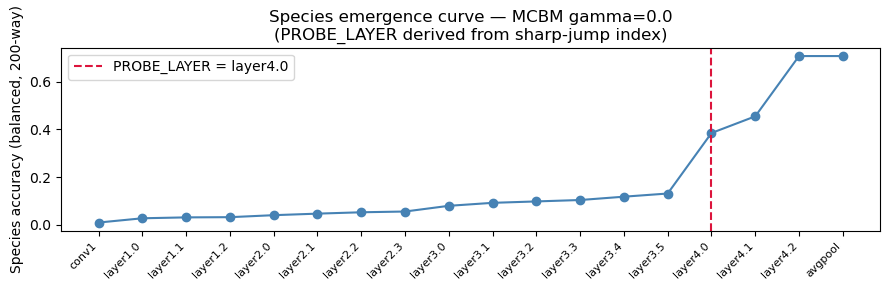

PROBE_LAYER = 'layer4.0'


In [20]:
# ── CELL 4-4: Species emergence plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(len(LAYERS)), species_curve, marker="o", color="steelblue")
ax.axvline(species_emerge_idx, color="crimson", ls="--",
           label=f"PROBE_LAYER = {PROBE_LAYER}")
ax.set_xticks(range(len(LAYERS)))
ax.set_xticklabels(LAYERS, rotation=45, ha="right", fontsize=8)
ax.set_ylabel(f"Species accuracy ({EMERGE_METRIC}, 200-way)")
ax.set_title("Species emergence curve — MCBM gamma=0.0\n"
             "(PROBE_LAYER derived from sharp-jump index)")
ax.legend(); plt.tight_layout()
plt.savefig("mcbm_species_emergence_curve.png", dpi=150)
plt.show()
print(f"PROBE_LAYER = {PROBE_LAYER!r}")

In [21]:
# ── CELL 5-1: run_one_attribute ───────────────────────────────────────────────
# BUG 6 FIX: Xtr_all and Xte_all are passed in (pre-loaded by the caller).
# BUG 3 FIX: df_te.reset_index(drop=True) before passing to add_species_bootstrap_ci
#            is already guaranteed because align_features_and_labels always builds
#            a fresh DataFrame — but we enforce it explicitly here for safety.

def run_one_attribute(
    attr_name: str,
    Xtr_all: torch.Tensor,
    Xte_all: torch.Tensor,
    *,
    min_certainty: int = 1,
    thr: float = 0.5,
    epochs: int = 25,
    min_each: int = 10,
    n_pairs: int = 200,
    B_gap: int = 100,
    B_species: int = 100,
):
    aid       = attr_name_to_id[attr_name]
    lab       = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=min_certainty)
    lab_train = lab[lab["is_train"]==1].copy()
    lab_test  = lab[lab["is_train"]==0].copy()

    Xtr, df_tr = align_features_and_labels(Xtr_all, mcbm_ids_tr, lab_train)
    Xte, df_te = align_features_and_labels(Xte_all, mcbm_ids_te, lab_test)
    df_te      = df_te.reset_index(drop=True)   # explicit safety guarantee

    ytr = df_tr["y"].astype(int).to_numpy()
    yte = df_te["y"].astype(int).to_numpy()

    probe = train_probe(Xtr, ytr, seed=0, epochs=epochs)
    probs = predict_probs(probe, Xte)

    species_table = add_species_bootstrap_ci(df_te, probs, thr=thr, B=B_species)
    test_acc      = float(((probs>=thr).astype(int)==yte).mean()) if len(yte) else np.nan

    if int(n_pairs) <= 0:
        pairs        = []
        pair_summary = pd.DataFrame()
    else:
        pairs        = make_candidate_pairs(df_te, min_each=min_each, max_pairs=n_pairs, seed=0)
        pair_summary = matched_pair_bootstrap_summary(df_te, probs, pairs, thr=thr, B=B_gap)

    mean_gap = float(pair_summary["gap_mean"].mean())        if len(pair_summary) else np.nan
    p90_gap  = float(pair_summary["gap_mean"].quantile(0.9)) if len(pair_summary) else np.nan

    info = {
        "attr": attr_name, "layer": PROBE_LAYER,
        "n_train": int(len(df_tr)), "n_test": int(len(df_te)),
        "train_pos_rate": float(ytr.mean()) if len(ytr) else np.nan,
        "test_pos_rate":  float(yte.mean()) if len(yte) else np.nan,
        "test_acc": test_acc, "thr": thr, "epochs": epochs,
        "n_pairs": int(len(pairs)), "B_gap": B_gap, "B_species": B_species,
        "mean_gap": mean_gap, "p90_gap": p90_gap,
    }
    return info, pair_summary, df_te, species_table

In [22]:
# ── CELL 5-2: Attribute screening ────────────────────────────────────────────
# BUG 6 FIX: features loaded once before the attribute loop.
# BUG 9 FIX: no max_attrs cap; candidates shuffled with fixed seed so the limit
#            (if any) is random rather than systematically excluding high-id attrs.

def screen_attributes(
    candidate_attrs,
    feat_dir: Path,
    layer: str,
    *,
    min_certainty=1, thr=0.5,
    min_pos_per_species=10, min_species_with_pos=15,
    min_overall_prev=0.05, max_overall_prev=0.95,
    epochs=8, verbose_every=50, B_species=200,
):
    # BUG 6 FIX: load once
    Xtr_all = load_features(feat_dir, layer, "train")
    Xte_all = load_features(feat_dir, layer, "test")

    rows, errors = [], []
    stats = {"tried":0,"success":0,"filtered_too_few_species_pos":0,
             "filtered_prev_out_of_range":0,"filtered_no_recall_vals":0,"errored":0}

    for i, attr in enumerate(candidate_attrs):
        stats["tried"] += 1
        try:
            info, _, _, st = run_one_attribute(
                attr, Xtr_all, Xte_all,
                min_certainty=min_certainty, thr=thr,
                epochs=epochs, n_pairs=0, B_species=B_species,
            )
            overall_prev  = float(st["n_pos"].sum()/st["n"].sum()) if st["n"].sum()>0 else np.nan
            st_pos        = st[st["n_pos"] >= min_pos_per_species]
            n_species_pos = int(len(st_pos))
            if n_species_pos < min_species_with_pos:
                stats["filtered_too_few_species_pos"] += 1; continue
            if not (min_overall_prev <= overall_prev <= max_overall_prev):
                stats["filtered_prev_out_of_range"] += 1; continue
            recall_vals = st_pos["recall"].dropna().to_numpy()
            if recall_vals.size == 0:
                stats["filtered_no_recall_vals"] += 1; continue
            stats["success"] += 1
            rows.append({
                "attr": attr, "overall_prev": overall_prev,
                "n_species_pos": n_species_pos,
                "recall_std":     float(np.std(recall_vals)),
                "recall_range":   float(np.max(recall_vals)-np.min(recall_vals)),
                "recall_p90_p10": float(np.quantile(recall_vals,0.9)-np.quantile(recall_vals,0.1)),
                "test_acc": float(info["test_acc"]),
            })
            if verbose_every and (i+1)%verbose_every==0:
                print(f"[{i+1}/{len(candidate_attrs)}] {attr}  "
                      f"prev={overall_prev:.3f}  n_sp={n_species_pos}")
        except Exception as e:
            stats["errored"] += 1
            if len(errors) < 5: errors.append((attr, repr(e)))

    print("\n--- Screening summary ---")
    for k, v in stats.items(): print(f"  {k}: {v}")
    if errors: print("Errors (first 5):", errors)
    if not rows: return pd.DataFrame()
    return (pd.DataFrame(rows)
              .sort_values(["recall_p90_p10","recall_range","recall_std"], ascending=False)
              .reset_index(drop=True))

In [24]:
# ── CELL 5-3: Run screening → ATTR_LIST ──────────────────────────────────────
# BUG 9 FIX: shuffle all 312 candidates with fixed seed before screening.
# Previously max_attrs=200 silently dropped the upper 112 attributes by id order.

_all_attrs = attr_df["attr_name"].tolist()
random.seed(42)
_shuffled  = random.sample(_all_attrs, len(_all_attrs))

screen_df = screen_attributes(
    _shuffled, MCBM_FEATS[0.0], layer=PROBE_LAYER,
    min_certainty=1, thr=0.5,
    min_pos_per_species=10, min_species_with_pos=15,
    min_overall_prev=0.05, max_overall_prev=0.95,
    epochs=8, verbose_every=25,
)

if screen_df.empty:
    print("Loosening filters…")
    screen_df = screen_attributes(
        _shuffled, MCBM_FEATS[0.0], layer=PROBE_LAYER,
        min_certainty=1, thr=0.5,
        min_pos_per_species=5, min_species_with_pos=8,
        min_overall_prev=0.02, max_overall_prev=0.98,
        epochs=6, verbose_every=25,
    )

ATTR_LIST = screen_df["attr"].tolist()
print(f"\nATTR_LIST ({len(ATTR_LIST)}):")
for a in ATTR_LIST: print(f"  {a}")
screen_df.head(20)

[50/312] has_wing_color::buff  prev=0.183  n_sp=40
[175/312] has_nape_color::yellow  prev=0.080  n_sp=15
[225/312] has_bill_shape::cone  prev=0.253  n_sp=56

--- Screening summary ---
  tried: 312
  success: 114
  filtered_too_few_species_pos: 198
  filtered_prev_out_of_range: 0
  filtered_no_recall_vals: 0
  errored: 0

ATTR_LIST (114):
  has_upperparts_color::black
  has_bill_length::about_the_same_as_head
  has_wing_shape::rounded-wings
  has_bill_shape::all-purpose
  has_wing_color::black
  has_tail_pattern::multi-colored
  has_breast_pattern::solid
  has_under_tail_color::black
  has_upper_tail_color::white
  has_wing_color::grey
  has_bill_color::black
  has_wing_color::white
  has_size::very_small_(3_-_5_in)
  has_upperparts_color::grey
  has_wing_pattern::striped
  has_bill_length::shorter_than_head
  has_head_pattern::capped
  has_bill_shape::cone
  has_primary_color::black
  has_under_tail_color::white
  has_throat_color::white
  has_nape_color::brown
  has_underparts_color::

,attr,overall_prev,n_species_pos,recall_std,recall_range,recall_p90_p10,test_acc
0,has_upperparts_color::black,0.392302,106,0.300587,1.000000,0.838889,0.689679
1,has_bill_length::about_the_same_as_head,0.365723,91,0.308007,1.000000,0.800000,0.701415
2,has_wing_shape::rounded-wings,0.285295,67,0.277103,1.000000,0.779814,0.587332
3,has_bill_shape::all-purpose,0.403348,109,0.295916,1.000000,0.779365,0.655678
4,has_wing_color::black,0.424750,115,0.289191,0.928571,0.766207,0.668105
5,has_tail_pattern::multi-colored,0.234208,55,0.276478,1.000000,0.762747,0.660166
6,has_breast_pattern::solid,0.544356,154,0.278089,1.000000,0.757790,0.652917
7,has_under_tail_color::black,0.312047,76,0.276194,0.961538,0.726496,0.713324
8,has_upper_tail_color::white,0.125992,27,0.292769,0.900000,0.716538,0.845702
9,has_wing_color::grey,0.305143,83,0.253084,1.000000,0.699064,0.682085


In [25]:
# ── CELL 6-1: run_many ────────────────────────────────────────────────────────
# BUG 6 FIX: features loaded once per (gamma, layer), shared across all attributes.

def run_many(attr_list, model_name, feat_dir, *,
             layer, min_certainty=1, thr=0.5, epochs=25, min_each=10,
             n_pairs=200, B_gap=100, B_species=100):
    # single load for the whole attribute sweep
    Xtr_all = load_features(feat_dir, layer, "train")
    Xte_all = load_features(feat_dir, layer, "test")

    all_info, all_pair_summ, all_species = [], [], []
    for attr in attr_list:
        info, pair_summ, _, species_table = run_one_attribute(
            attr, Xtr_all, Xte_all,
            min_certainty=min_certainty, thr=thr, epochs=epochs,
            min_each=min_each, n_pairs=n_pairs, B_gap=B_gap, B_species=B_species,
        )
        info = dict(info); info["model"] = model_name
        all_info.append(info)
        if pair_summ is not None and len(pair_summ):
            ps = pair_summ.copy(); ps["attr"] = attr; ps["model"] = model_name
            all_pair_summ.append(ps)
        st = species_table.copy(); st["attr"] = attr; st["model"] = model_name
        all_species.append(st)
        print(f"{model_name}  {attr}  "
              f"test_acc={info['test_acc']:.4f}  mean_gap={info['mean_gap']:.4f}")

    return (pd.DataFrame(all_info),
            pd.concat(all_pair_summ, ignore_index=True) if all_pair_summ else pd.DataFrame(),
            pd.concat(all_species,   ignore_index=True) if all_species   else pd.DataFrame())

In [26]:
# ── CELL 6-2: Run the sweep ───────────────────────────────────────────────────
# BUG 8 FIX: GAMMAS already defined in Cell 0-2 — never redefine it here.
# Filter to dirs that exist; warn about any missing.

_active = [g for g in GAMMAS if MCBM_FEATS[g].exists()]
_missing = [g for g in GAMMAS if not MCBM_FEATS[g].exists()]
if _missing:
    print(f"WARNING: skipping gammas with no feature dir: {_missing}")
print(f"Running sweep: {_active}  (PROBE_LAYER={PROBE_LAYER})")

mcbm_results = {}   # g -> (info_df, pairs_df, species_df)

for g in _active:
    print(f"\n{'='*60}\n  MCBM gamma={g}   PROBE_LAYER={PROBE_LAYER}\n{'='*60}")
    info, pairs, species = run_many(
        ATTR_LIST, f"mcbm_gamma{g}", MCBM_FEATS[g],
        layer=PROBE_LAYER, thr=0.5, n_pairs=200, B_gap=100, B_species=100,
    )
    mcbm_results[g] = (info, pairs, species)
    species.to_csv(f"mcbm_species_gamma{g}.csv", index=False)
    print(f"Saved mcbm_species_gamma{g}.csv ({len(species)} rows)")

print("\nSweep complete.")

Running sweep: [0.0, 0.1, 0.5, 1.0]  (PROBE_LAYER=layer4.0)

  MCBM gamma=0.0   PROBE_LAYER=layer4.0
mcbm_gamma0.0  has_upperparts_color::black  test_acc=0.7018  mean_gap=0.3239
mcbm_gamma0.0  has_bill_length::about_the_same_as_head  test_acc=0.6702  mean_gap=0.3070
mcbm_gamma0.0  has_wing_shape::rounded-wings  test_acc=0.4695  mean_gap=0.2246
mcbm_gamma0.0  has_bill_shape::all-purpose  test_acc=0.6845  mean_gap=0.3480
mcbm_gamma0.0  has_wing_color::black  test_acc=0.6876  mean_gap=0.3363
mcbm_gamma0.0  has_tail_pattern::multi-colored  test_acc=0.7176  mean_gap=0.2608
mcbm_gamma0.0  has_breast_pattern::solid  test_acc=0.6754  mean_gap=0.2934
mcbm_gamma0.0  has_under_tail_color::black  test_acc=0.5618  mean_gap=0.1737
mcbm_gamma0.0  has_upper_tail_color::white  test_acc=0.8473  mean_gap=0.3940
mcbm_gamma0.0  has_wing_color::grey  test_acc=0.6859  mean_gap=0.3078
mcbm_gamma0.0  has_bill_color::black  test_acc=0.6526  mean_gap=0.3242
mcbm_gamma0.0  has_wing_color::white  test_acc=0.7133  

In [27]:
# ── CELL 7-1: Per-attribute summary utilities ─────────────────────────────────
def add_gap_interpretability_cols(pair_df: pd.DataFrame) -> pd.DataFrame:
    out = pair_df.copy()
    out["gap_snr"]  = out["gap_mean"] / out["gap_std"].replace(0, np.nan)
    out["gap_norm"] = out["gap_mean"]
    return out

def summarize_by_attr(pairs_df: pd.DataFrame) -> pd.DataFrame:
    if pairs_df.empty: return pairs_df
    tmp = pairs_df.copy()
    tmp["_ci_above0"] = tmp["gap_ci_lo"] > 0
    tmp["_p_small"]   = tmp["gap_p"] <= 0.05
    return (
        tmp.groupby(["model","attr"], as_index=False)
           .agg(gap_mean       =("gap_mean",    "mean"),
                gap_median     =("gap_mean",    "median"),
                gap_max        =("gap_mean",    "max"),
                n_pairs        =("gap_mean",    "size"),
                frac_p_small   =("_p_small",    "mean"),
                frac_ci_above0 =("_ci_above0",  "mean"),
                gap_snr_mean   =("gap_snr",     "mean"))
           .sort_values(["model","gap_mean"], ascending=[True, False])
    )

def top_pairs(pairs_df: pd.DataFrame, model: str, attr: str, k: int = 10) -> pd.DataFrame:
    sub  = pairs_df[(pairs_df["model"]==model) & (pairs_df["attr"]==attr)].copy()
    cols = [c for c in ["species_A","species_B","gap_mean","gap_ci_lo","gap_ci_hi",
                         "gap_p","gap_std","gap_snr","npos","n_runs"] if c in sub.columns]
    return sub.sort_values("gap_mean", ascending=False).head(k)[cols]

In [28]:
# ── CELL 7-2: Per-attribute summary — all gammas ──────────────────────────────
all_summaries = {}

for g, (_, pairs, _) in mcbm_results.items():
    if pairs.empty:
        print(f"gamma={g}: no pairs data"); continue
    pairs_enr = add_gap_interpretability_cols(pairs)
    s = summarize_by_attr(pairs_enr)
    all_summaries[g] = s
    print(f"\n{'='*55}")
    print(f"  Per-attribute summary  gamma={g}  PROBE_LAYER={PROBE_LAYER}")
    print(f"{'='*55}")
    display(s)


  Per-attribute summary  gamma=0.0  PROBE_LAYER=layer4.0


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
38,mcbm_gamma0.0,has_crown_color::white,0.425758,0.306667,1.000000,200,0.455,0.515,3.345465
40,mcbm_gamma0.0,has_eye_color::black,0.409296,0.354755,1.000000,200,0.535,0.580,2.819235
96,mcbm_gamma0.0,has_upper_tail_color::white,0.393973,0.370742,0.848000,200,0.480,0.545,2.784344
58,mcbm_gamma0.0,has_nape_color::white,0.368087,0.295714,1.000000,200,0.405,0.455,2.609649
18,mcbm_gamma0.0,has_bill_color::grey,0.355489,0.316227,0.935000,200,0.360,0.465,2.400054
...,...,...,...,...,...,...,...,...,...
108,mcbm_gamma0.0,has_wing_color::yellow,0.089350,0.048429,0.413000,200,0.075,0.110,1.493086
39,mcbm_gamma0.0,has_crown_color::yellow,0.085670,0.097273,0.162727,200,0.000,0.000,1.256253
66,mcbm_gamma0.0,has_shape::gull-like,0.070385,0.065549,0.246154,200,0.025,0.045,1.277377
102,mcbm_gamma0.0,has_upperparts_color::yellow,0.066878,0.060801,0.254000,200,0.005,0.010,1.271488



  Per-attribute summary  gamma=0.1  PROBE_LAYER=layer4.0


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
38,mcbm_gamma0.1,has_crown_color::white,0.424482,0.383333,0.921818,200,0.495,0.545,3.116190
40,mcbm_gamma0.1,has_eye_color::black,0.423534,0.428346,0.956000,200,0.535,0.600,3.428111
96,mcbm_gamma0.1,has_upper_tail_color::white,0.379663,0.361250,0.763000,200,0.465,0.515,2.549277
26,mcbm_gamma0.1,has_breast_color::brown,0.375901,0.285833,0.933000,200,0.450,0.490,3.043286
17,mcbm_gamma0.1,has_bill_color::buff,0.373920,0.307803,1.000000,200,0.410,0.470,2.609339
...,...,...,...,...,...,...,...,...,...
25,mcbm_gamma0.1,has_breast_color::black,0.103875,0.099083,0.261818,200,0.055,0.065,1.358671
70,mcbm_gamma0.1,has_size::very_small_(3_-_5_in),0.079864,0.000000,0.417273,200,0.060,0.085,1.462553
102,mcbm_gamma0.1,has_upperparts_color::yellow,0.055561,0.063929,0.182308,200,0.000,0.010,1.150964
59,mcbm_gamma0.1,has_nape_color::yellow,0.051559,0.000000,0.151333,200,0.000,0.000,1.480335



  Per-attribute summary  gamma=0.5  PROBE_LAYER=layer4.0


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
38,mcbm_gamma0.5,has_crown_color::white,0.419439,0.333667,0.918000,200,0.455,0.495,3.372212
40,mcbm_gamma0.5,has_eye_color::black,0.390722,0.325500,0.916364,200,0.455,0.520,2.958024
17,mcbm_gamma0.5,has_bill_color::buff,0.382158,0.353000,0.918000,200,0.450,0.530,2.639519
20,mcbm_gamma0.5,has_bill_length::shorter_than_head,0.367780,0.314059,1.000000,200,0.455,0.545,2.772014
26,mcbm_gamma0.5,has_breast_color::brown,0.359588,0.267902,0.845000,200,0.430,0.455,2.642438
...,...,...,...,...,...,...,...,...,...
24,mcbm_gamma0.5,has_bill_shape::hooked_seabird,0.084426,0.071429,0.219000,200,0.000,0.000,1.210573
94,mcbm_gamma0.5,has_upper_tail_color::buff,0.083885,0.076364,0.330000,200,0.040,0.050,1.217212
59,mcbm_gamma0.5,has_nape_color::yellow,0.077129,0.000000,0.241667,200,0.070,0.125,1.887648
39,mcbm_gamma0.5,has_crown_color::yellow,0.064500,0.056189,0.162143,200,0.000,0.000,1.293065



  Per-attribute summary  gamma=1.0  PROBE_LAYER=layer4.0


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
38,mcbm_gamma1.0,has_crown_color::white,0.421665,0.396500,0.921818,200,0.510,0.555,3.397098
0,mcbm_gamma1.0,has_back_color::black,0.367315,0.303636,1.000000,200,0.405,0.500,2.613587
40,mcbm_gamma1.0,has_eye_color::black,0.366593,0.328615,1.000000,200,0.465,0.505,2.801891
17,mcbm_gamma1.0,has_bill_color::buff,0.363681,0.325500,0.895000,200,0.350,0.480,2.418068
21,mcbm_gamma1.0,has_bill_shape::all-purpose,0.358817,0.306515,1.000000,200,0.400,0.450,2.629008
...,...,...,...,...,...,...,...,...,...
94,mcbm_gamma1.0,has_upper_tail_color::buff,0.108438,0.093182,0.322000,200,0.085,0.095,1.403393
108,mcbm_gamma1.0,has_wing_color::yellow,0.099758,0.056333,0.520000,200,0.075,0.100,1.366721
66,mcbm_gamma1.0,has_shape::gull-like,0.075126,0.081224,0.223000,200,0.000,0.000,1.215374
39,mcbm_gamma1.0,has_crown_color::yellow,0.074610,0.069268,0.162143,200,0.000,0.000,1.162640


In [29]:
# ── CELL 7-3: Sanity check — gamma=0.0 vs cbm_species.csv ────────────────────
import os
_cbm_csv = "cbm_species.csv"
if os.path.exists(_cbm_csv):
    cbm_ref = pd.read_csv(_cbm_csv)
    _, _, species_g0 = mcbm_results[0.0]
    _g0   = species_g0.groupby("attr")["recall"].mean().rename("recall_mcbm_g0")
    _cbm  = cbm_ref.groupby("attr")["recall"].mean().rename("recall_cbm")
    _comp = pd.concat([_g0, _cbm], axis=1).dropna()
    _comp["delta"] = _comp["recall_mcbm_g0"] - _comp["recall_cbm"]
    print("Sanity: gamma=0.0 vs cbm_species.csv  (delta should be ~0)")
    display(_comp)
else:
    print(f"Skipped: {_cbm_csv} not found. Run recall.ipynb first to enable this check.")

Sanity: gamma=0.0 vs cbm_species.csv  (delta should be ~0)


,recall_mcbm_g0,recall_cbm,delta
attr,,,
has_bill_length::shorter_than_head,0.566377,0.577344,-0.010967
has_bill_shape::all-purpose,0.409964,0.370809,0.039155
has_breast_color::white,0.503602,0.582392,-0.078790
has_breast_pattern::solid,0.677989,0.551072,0.126917
has_under_tail_color::black,0.682915,0.513105,0.169811
has_under_tail_color::white,0.349963,0.538931,-0.188967
has_upper_tail_color::white,0.207231,0.356305,-0.149074
has_upperparts_color::black,0.382911,0.513773,-0.130861
has_upperparts_color::brown,0.566666,0.473304,0.093363


In [30]:
# ── CELL 7-4: Top species pairs per gamma ────────────────────────────────────
for g, (_, pairs, _) in mcbm_results.items():
    if pairs.empty: print(f"gamma={g}: no pairs"); continue
    pairs_enr = add_gap_interpretability_cols(pairs)
    print(f"\n{'='*60}")
    print(f"  Top species pairs  gamma={g}  PROBE_LAYER={PROBE_LAYER}")
    print(f"{'='*60}")
    for attr in ATTR_LIST:
        print(f"\n  Attribute: {attr}")
        display(top_pairs(pairs_enr, f"mcbm_gamma{g}", attr, k=5))


  Top species pairs  gamma=0.0  PROBE_LAYER=layer4.0

  Attribute: has_upperparts_color::black


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,npos,n_runs
0,Rose breasted Grosbeak,Yellow Warbler,1.000000,1.000000,1.0,0.0,0.000000,NaN,15,100
1,Rose breasted Grosbeak,Prairie Warbler,0.911538,0.769231,1.0,0.0,0.077211,11.805811,13,100
2,Canada Warbler,Pied Kingfisher,0.901000,0.700000,1.0,0.0,0.093268,9.660289,10,100
3,Canada Warbler,Brewer Blackbird,0.859000,0.547500,1.0,0.0,0.122552,7.009268,10,100
4,Pied Kingfisher,Great Grey Shrike,0.838235,0.647059,1.0,0.0,0.092026,9.108640,17,100



  Attribute: has_bill_length::about_the_same_as_head


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,npos,n_runs
200,Western Grebe,Orchard Oriole,0.926667,0.800000,1.0,0.0,0.067659,13.696077,15,100
201,Long tailed Jaeger,Orchard Oriole,0.924000,0.800000,1.0,0.0,0.066010,13.997858,15,100
202,Baltimore Oriole,Western Grebe,0.922727,0.727273,1.0,0.0,0.076466,12.067097,11,100
203,Horned Puffin,Orchard Oriole,0.850714,0.642857,1.0,0.0,0.099023,8.591052,14,100
204,Louisiana Waterthrush,Orchard Oriole,0.843000,0.600000,1.0,0.0,0.115978,7.268592,10,100



  Attribute: has_wing_shape::rounded-wings


...

,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,npos,n_runs
22200,Black footed Albatross,Red faced Cormorant,0.423,0.1475,0.7,0.02,0.146871,2.880084,10,100
22201,Pomarine Jaeger,Red faced Cormorant,0.421,0.2000,0.7,0.00,0.149195,2.821820,10,100
22202,Red faced Cormorant,Black footed Albatross,0.413,0.1000,0.7,0.02,0.152089,2.715519,10,100
22203,Pomarine Jaeger,Red faced Cormorant,0.408,0.1000,0.7,0.00,0.144000,2.833333,10,100
22204,Black footed Albatross,Red faced Cormorant,0.403,0.1000,0.7,0.00,0.153268,2.629386,10,100



  Attribute: has_throat_color::yellow


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,npos,n_runs
22400,Nashville Warbler,Horned Lark,0.360000,0.111111,0.584722,0.00,0.122595,2.936489,18,100
22401,Horned Lark,Nashville Warbler,0.353333,0.111111,0.611111,0.00,0.127299,2.775626,18,100
22402,Nashville Warbler,Horned Lark,0.347222,0.111111,0.584722,0.02,0.116103,2.990636,18,100
22403,Horned Lark,Nashville Warbler,0.339444,0.137500,0.584722,0.00,0.122700,2.766462,18,100
22404,Hooded Warbler,Horned Lark,0.332500,0.000000,0.627083,0.12,0.161372,2.060455,12,100



  Attribute: has_nape_color::yellow


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,npos,n_runs
22600,Hooded Warbler,Worm eating Warbler,0.363571,0.142857,0.642857,0.02,0.130968,2.776038,14,100
22601,Yellow throated Vireo,Worm eating Warbler,0.363333,0.166667,0.583333,0.00,0.123895,2.932588,12,100
22602,Worm eating Warbler,Hooded Oriole,0.360667,0.133333,0.568333,0.00,0.119292,3.023385,15,100
22603,Worm eating Warbler,Hooded Warbler,0.352857,0.142857,0.571429,0.02,0.125690,2.807362,14,100
22604,Blue winged Warbler,Worm eating Warbler,0.350000,0.098333,0.600000,0.00,0.118650,2.949857,15,100


In [31]:
# ── CELL 7-5: Species recall table — gamma=0.0 ───────────────────────────────
_, _, species_g0 = mcbm_results[0.0]
print(f"MCBM gamma=0.0 species recall (sorted by tp, PROBE_LAYER={PROBE_LAYER}):")
display(species_g0.sort_values("tp", ascending=False).head(30))

MCBM gamma=0.0 species recall (sorted by tp, PROBE_LAYER=layer4.0):


,species_id,species_name,n,n_pos,n_pred_pos,n_neg,prevalence,tp,recall,precision,recall_bs_mean,recall_ci_lo,recall_ci_hi,recall_ci_width,B,attr,model
7648,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_eye_color::black,mcbm_gamma0.0
21048,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_belly_color::yellow,mcbm_gamma0.0
1317,29,American Crow,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_breast_pattern::solid,mcbm_gamma0.0
7631,99,Ovenbird,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_eye_color::black,mcbm_gamma0.0
22448,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_throat_color::yellow,mcbm_gamma0.0
7665,199,Winter Wren,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_eye_color::black,mcbm_gamma0.0
14848,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_primary_color::yellow,mcbm_gamma0.0
14850,182,Yellow Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_primary_color::yellow,mcbm_gamma0.0
858,192,Downy Woodpecker,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_wing_color::black,mcbm_gamma0.0
7718,35,Purple Finch,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_eye_color::black,mcbm_gamma0.0


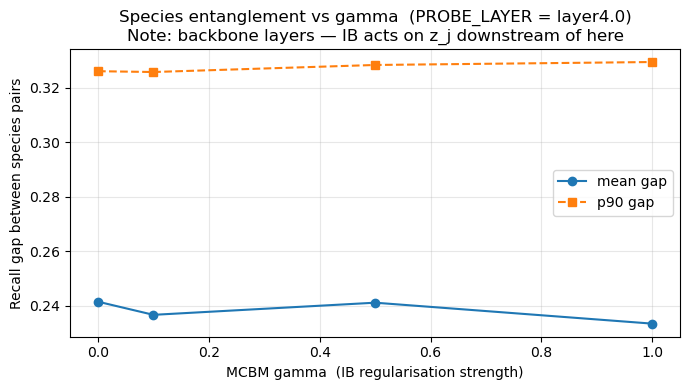

   gamma  mean_gap   p90_gap
0    0.0  0.241505  0.326054
1    0.1  0.236683  0.325756
2    0.5  0.241139  0.328339
3    1.0  0.233453  0.329423


In [32]:
# ── CELL 7-6: Gap vs gamma summary plot ──────────────────────────────────────
rows = []
for g, (info_df, pairs, _) in mcbm_results.items():
    if pairs.empty: continue
    s = summarize_by_attr(add_gap_interpretability_cols(pairs))
    rows.append({"gamma": g, "mean_gap": float(s["gap_mean"].mean()),
                 "p90_gap": float(s["gap_mean"].quantile(0.9))})

gap_trend = pd.DataFrame(rows).sort_values("gamma")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(gap_trend["gamma"], gap_trend["mean_gap"],  marker="o", label="mean gap")
ax.plot(gap_trend["gamma"], gap_trend["p90_gap"],   marker="s", ls="--", label="p90 gap")
ax.set_xlabel("MCBM gamma  (IB regularisation strength)")
ax.set_ylabel("Recall gap between species pairs")
ax.set_title(f"Species entanglement vs gamma  (PROBE_LAYER = {PROBE_LAYER})\n"
             "Note: backbone layers — IB acts on z_j downstream of here")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mcbm_gap_vs_gamma.png", dpi=150)
plt.show()
print(gap_trend)